# 1. Espacios de Probabilidad

## 1.1 Probabilidad Clásica 

### Un espacio de probabilidad se encuentra caracterizado por tres componentes: $(\Omega, \mathcal{F}, \mathbb{P})$. $\Omega$ representa el espacio muestral, el cual esta conformado por los posibles resultados de un experimento aleatorio. La siguiente componente es el espacio de eventos $\mathcal{F}$, el cual es un subconjunto de $\mathcal{Pot}(\Omega)$. Finalmente, $\mathbb{P}:\mathcal{F}\rightarrow [0,1]$ es la medida de probabilidad. 

### Existen tres enfoques para abordar la medida de probabilidad en función de la cardinalidad del espacio muestral $\Omega$. Iniciemos con el caso finito, para este caso se considera la medida de probabilidad dada por:
$\begin{align} \mathbb{P}(A)=\frac{\mathcal{Card}(A)}{\mathcal{Card}(\Omega)}, A\in \mathcal{F}.\end{align} $

### Un módulo de Python que puede servir de apoyo en el cálculo de probabilidades es [`itertools`](https://docs.python.org/3/library/itertools.html).

### El módulo `itertools` de Python ofrece un conjunto de herramientas para construir y manipular iteradores de manera rápida, eficiente y con bajo consumo de memoria. Estas herramientas pueden usarse de forma individual o combinarse entre sí para crear procesos más complejos de manera sencilla.

### En ciencia de datos, `itertools` es especialmente útil cuando se trabaja con grandes volúmenes de información o con procesos que requieren generar combinaciones, permutaciones, agrupamientos o recorridos secuenciales sin cargar todos los datos en memoria al mismo tiempo.

### Entre sus aplicaciones más relevantes se encuentran:

- ### generación de **combinaciones** y **permutaciones** para análisis exploratorio o búsqueda de escenarios;
- ### creación de **productos cartesianos** para evaluar configuraciones de variables;

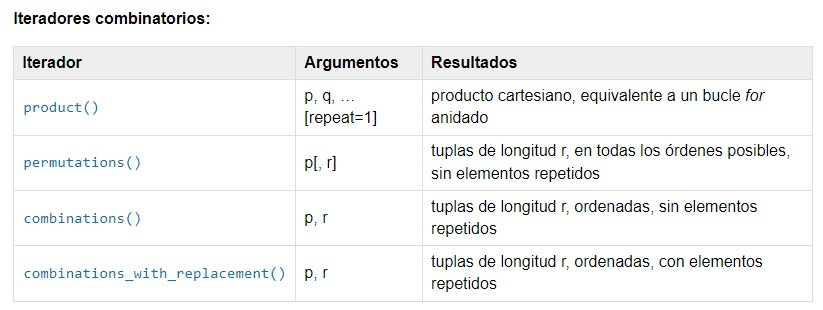

### Ejemplo 1.1.1: Lanzamiento de dos dados

### Consideremos el experimento aleatorio de lanzar dos dados. En este caso el espacio muestral esta dado por $\begin{align} \Omega=\{(i,j):i, j\in \{1,2,..., 6\}\}.\end{align}$ El espacio de eventos es $\mathcal{F}=\mathcal{Pot}(\Omega)$. 

In [1]:
from itertools import product

Omega=set(product({1,2,3,4,5,6}, repeat=2))
Omega

{(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6)}

### Consideremos el siguiente evento: $\begin{align} E_n=\{(i,j)\in \Omega: i+j=n\}, \end{align}$ con $n\in \{2,..., 12\}$.

In [3]:
def E(n):
    E_n=set((i,j) for (i,j) in Omega if i+j==n)
    return E_n

In [3]:
E(2)

{(1, 1)}

In [4]:
E(5)

{(1, 4), (2, 3), (3, 2), (4, 1)}

### Calcular la probabilidad de que al lanzar dos dados obtengamos un 5: $\begin{align} \mathbb{P}(E_5)=\frac{\mathcal{Card}(E_5)}{\mathcal{Card}(\Omega)}\end{align}$

In [5]:
len(E(5))/len(Omega)

0.1111111111111111

In [6]:
len(E(12))/len(Omega)

0.027777777777777776

### Ahora supongamos que deseamos calcular la probabilidad de obtener un número impar, podemos calcularlo del modo siguiente: $\begin{align} C_2=\{(i,j)\in \Omega:(i+j)\nmid 2\}.\end{align}$

In [ ]:
def C(n):
    C_n=set((i,j) for (i,j) in Omega if (i+j)%n==0) #observar si divibles por 2
    return C_n

def C_c(n):
    C_n=set((i,j) for (i,j) in Omega if (i+j)%n!=0) #ya no divisibles por 2
    return C_n

In [8]:
1-len(C(2))/len(Omega)

0.5

In [8]:
len(C_c(2))/len(Omega)

0.5

In [9]:
len(C(3))/len(Omega)

0.3333333333333333

## 1.1.2 Urna

| Tipo de muestra | Ordenada | No ordenada |
|---|---:|---:|
| Con reemplazo | $M^n$ | $\binom{M+n-1}{n}=\dfrac{(M+n-1)!}{n!(M-1)!}$ |
| Sin reemplazo | $(M)_n=M(M-1)(M-2)\cdots(M-n+1)=\dfrac{M!}{(M-n)!}$ | $\binom{M}{n}=\dfrac{M!}{n!(M-n)!}$ |

In [10]:
set(product({'a', 'b', 'c'}, repeat=2)) #reemplazo ordenando

{('a', 'a'),
 ('a', 'b'),
 ('a', 'c'),
 ('b', 'a'),
 ('b', 'b'),
 ('b', 'c'),
 ('c', 'a'),
 ('c', 'b'),
 ('c', 'c')}

In [11]:
from itertools import combinations_with_replacement #reemplazo no orden

set(combinations_with_replacement({'a', 'b', 'c'}, 2))

{('a', 'a'), ('a', 'b'), ('a', 'c'), ('b', 'b'), ('b', 'c'), ('c', 'c')}

In [1]:
from itertools import permutations #sin orden

set(permutations({'a', 'b', 'c'}, 2))

{('a', 'b'), ('a', 'c'), ('b', 'a'), ('b', 'c'), ('c', 'a'), ('c', 'b')}

In [10]:
from itertools import combinations #sin no orden

set(combinations({'a', 'b', 'c'}, 2))

{('a', 'b'), ('a', 'c'), ('c', 'b')}

### **Ejemplo**: Una urna contiene 8 esferas rojas (R), 3 blancas (B) y 9 azules (A). Si se extraen 3 esferas aleatoriamente sin reemplazamiento, determinar la probabilidad de que las tres esferas sean rojas.

In [14]:
len(set(combinations(range(8), 3)))/len(set(combinations(range(20), 3)))

0.04912280701754386

### Determinar la probabilidad de obtener en la extracción al menos una blanca.

$\mathbb P$(al menos una blanca)=1-$\mathbb P$(ninguna blanca)

In [11]:
1-len(set(combinations(range(17), 3)))/len(set(combinations(range(20), 3)))

0.4035087719298246

In [ ]:
len(set(combinations(range(3), 3)))/len(set(combinations(range(20), 3))) #revisar

0.0008771929824561404

## 1.2 Probabilidad Frecuentista

### La siguiente definición es conocida como probabilidad frecuentista y es aplicable cuando podemos replicar el experimento aleatorio: $$\mathbb{P}(A)=\frac{\text{No. de veces que ocurre A}}{\text{Total de repeticiones del experimento}}.$$

### En este caso, un módulo de Python que puede servir de apoyo en el cálculo de probabilidades frecuentistas es [`random`](https://www.w3schools.com/Python/module_random.asp). Este módulo permite generar resultados aleatorios que imitan la repetición de experimentos, como lanzamientos de monedas, tiros de dados, extracción de bolas de una urna o selección de muestras. A partir de estas simulaciones, es posible aproximar probabilidades mediante la frecuencia relativa de ocurrencia de un evento cuando el experimento se repite un gran número de veces.

### Entre las funciones más útiles de este módulo se encuentran `random()`, que genera números aleatorios en el intervalo \([0,1)\); `randint(a,b)`, que devuelve enteros aleatorios en un rango dado; `choice()`, que selecciona un elemento de una secuencia; `sample()`, que permite obtener muestras sin reemplazo; y `choices()`, que permite muestreo con reemplazo.

Todo aqui es equiprobable

### Ejemplo 1.2.1

### Consideremos el ejemplo referente al lanzamiento de dos dados. Y calculemos la probabilidad de obtener un 5 desde el enfoque frecuentista.

### Solución:

In [16]:
import random

def lanzamiento(m):
    dado=[]
    for i in range(m):
        dado.append(random.choice(range(1,7))+random.choice(range(1,7)))
    return dado

In [17]:
lanzamiento(10)

[10, 7, 11, 6, 8, 5, 7, 8, 7, 5]

In [18]:
prueba=lanzamiento(1000)
cinco=[x for x in prueba if x==5]
len(cinco)/1000

0.117

In [19]:
def prob(n, m):
    if n<2 or n>12:
        print('Error')
    else:
        Lanz=lanzamiento(m)
    return len([x for x in prueba if x==n])/m

In [20]:
prob(12, 1000)

0.028

### $\textbf{Ejercicio 1.2.2}$

### Suponga que se lanza un dado y posteriormente una moneda, en caso de caer águila se obtiene la cantidad marcada en el dado en valor monetario, en caso contrario se gana 0. ¿Cuál es la probabilidad de que el capital del jugador sea de más de 100 u.m. en 50 lanzamientos?

### Solución:

In [21]:
def apuesta(m):
    capital=[]
    for i in range(m):
        if random.choice(range(0,2))==1:
            capital.append(random.choice(range(1,7)))
        else:
            capital.append(0)
    return capital

In [22]:
apuesta(10)

[3, 0, 6, 6, 3, 5, 0, 0, 0, 4]

In [23]:
escenarios=[sum(apuesta(50)) for _ in range(100000)]

In [24]:
len([x for x in escenarios if x>100])/100000

0.19304

# 1.3 Enfoque Axiomático / Kolmogorov

Sea $\Omega$ el **espacio muestral**, es decir, el conjunto de todos los resultados posibles de un experimento aleatorio, y sea $\mathcal{F}$ una **$\sigma$-álgebra** de subconjuntos de $\Omega$, cuyos elementos se llaman **eventos**. Una **probabilidad** es una función

$$
\mathbb P:\mathcal{F}\to[0,1]
$$

que satisface los siguientes axiomas:

### Axioma 1. No negatividad
Para todo evento $A\in\mathcal{F}$,

$
\mathbb P(A)\geq 0.
$

### Axioma 2. Normalización
La probabilidad del espacio muestral completo es 1:

$
\mathbb P(\Omega)=1.
$

### Axioma 3. $\sigma$-aditividad
Si $A_1,A_2,A_3,\dots$ es una sucesión de eventos mutuamente excluyentes, es decir,
$A_i\cap A_j=\varnothing \text{si } i\neq j,$ entonces

$$
\mathbb P\Big(\bigcup_{n=1}^{\infty} A_n\Big)=\sum_{n=1}^{\infty} \mathbb P(A_n).
$$

La terna $(\Omega,\mathcal{F},P)$ se denomina **espacio de probabilidad**.

## Algunas Propiedades

## Propiedades importantes de una medida de probabilidad

Sea $(\Omega,\mathcal{F},\mathbb P)$ un espacio de probabilidad. A partir de los axiomas de Kolmogorov se obtienen las siguientes propiedades:

### 1. Probabilidad del conjunto vacío
$$
\mathbb P(\varnothing)=0.
$$

### 2. Cotas de la probabilidad
Para todo evento $A\in\mathcal{F}$,
$$
0\leq P(A)\leq 1.
$$

### 3. Regla del complemento
Para todo evento $A\in\mathcal{F}$,
$$
\mathbb P(A^c)=1-\mathbb P(A).
$$

### 4. Monotonía
Si $A\subseteq B$, entonces
$$
\mathbb P(A)\leq \mathbb P(B).
$$

### 5. Diferencia de eventos
Si $A\subseteq B$, entonces
$$
\mathbb P(B\setminus A)=\mathbb P(B)-\mathbb P(A).
$$

### 6. Aditividad finita
Si $A$ y $B$ son disjuntos, es decir, $A\cap B=\varnothing$, entonces
$$
\mathbb P(A\cup B)=\mathbb P(A)+\mathbb P(B).
$$

Más generalmente, si $A_1,\dots,A_n$ son mutuamente excluyentes, entonces
$$
\mathbb P\Big(\bigcup_{i=1}^n A_i\Big)=\sum_{i=1}^n \mathbb P(A_i).
$$

### 7. Fórmula de la unión de dos eventos
Para cualesquiera eventos $A$ y $B$,
$$
\mathbb P(A\cup B)=\mathbb P(A)+\mathbb P(B)-\mathbb P(A\cap B).
$$

### 8. Subaditividad
Para cualquier sucesión de eventos $A_1,A_2,\dots$,
$$
\mathbb P\Big(\bigcup_{n=1}^{\infty} A_n\Big)\leq \sum_{n=1}^{\infty} \mathbb P(A_n).
$$

### 9. Continuidad creciente
Si $A_1\subseteq A_2\subseteq A_3\subseteq \cdots$, entonces
$$
\mathbb P\Big(\bigcup_{n=1}^{\infty} A_n\Big)=\lim_{n\to\infty} \mathbb P(A_n).
$$

### 10. Continuidad decreciente
Si $A_1\supseteq A_2\supseteq A_3\supseteq \cdots$, entonces
$$
\mathbb P\Big(\bigcap_{n=1}^{\infty} A_n\Big)=\lim_{n\to\infty} \mathbb P(A_n).
$$


### En el enfoque axiomático, una opción útil en Python es el módulo [`sympy`](https://www.sympy.org/es/), especialmente cuando se trabaja con variables aleatorias continuas. Este módulo permite realizar cálculos simbólicos, como integrar funciones, determinar constantes de normalización y verificar condiciones necesarias para que una función defina una densidad de probabilidad.

### En particular, si se propone una función $f(x)$ como posible densidad, `sympy` puede emplearse para imponer la condición

$$
\int_{\Omega} f(x)\,dx = 1,
$$

### y posteriormente calcular probabilidades de la forma

$$
\mathbb P(A)=\int_A f(x)\,dx.
$$

### Con este módulo se puede seguir el siguiente procedimiento:

1. Se propone una función $f(x)$ no negativa en su soporte.
2. Se impone la condición de normalización
   $$
   \int f(x)\,dx = 1.
   $$
3. Se determina la constante correspondiente.
4. Se verifica que la función resultante sea no negativa en todo su soporte.

## Ejemplo 1.3.1

### Supóngase que $X$ representa el tiempo de arribo (en horas) de un usuario a un módulo de atención durante las primeras dos horas de servicio. Se desea modelar una situación en la que las llegadas son poco frecuentes justo al abrir, aumentan durante la primera etapa del servicio y después disminuyen gradualmente hacia el final del intervalo.

### Una función que refleja este comportamiento es

$$
f(x)=
\begin{cases}
k\,x(2-x)^2, & 0\leq x\leq 2,\\
0, & \text{en otro caso}.
\end{cases}
$$

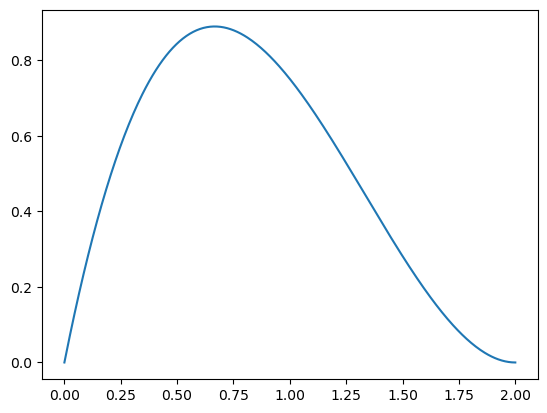

In [25]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(0, 2, 400)
f=(3/4)*x*(2-x)**2

plt.plot(x, f)
plt.show()

In [2]:
from sympy import symbols, integrate, Eq, solve

x, k=symbols('x k')

f=k*x*(2-x)**2
integral=integrate(f, (x, 0, 2))
solve(Eq(integral, 1), k)

[3/4]

### Entonces 
$$
f(x)=
\begin{cases}
\frac{3}{4}\,x(2-x)^2, & 0\leq x\leq 2,\\
0, & \text{en otro caso}.
\end{cases}
$$

### Calcular la probabilidad de que una persona llegue entre media hora y hora y media es

In [27]:
from sympy import Rational
t=symbols('t')
integrate(Rational(3,4)*t*(2-t)**2, (t, Rational(1,2), Rational(3,2))) #internalo A (1/2 a 3/4)

11/16